# 04. Самостоятельный кейс — преподавательское решение

Это эталонный маршрут, а не единственно допустимый набор графиков.

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    """Ищет корень учебного комплекта по наличию подготовленного датасета."""
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        target = candidate / "data" / "viz.csv"
        if target.exists():
            return candidate
    raise FileNotFoundError("Не найден data/viz.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "viz.csv"
OUTPUT_DIR = PROJECT_ROOT / "teacher" / "out"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data:", DATA_PATH)

Project root: <PROJECT_ROOT>\nData: <PROJECT_ROOT>/data/viz.csv\n

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)

pandas: 2.2.3
seaborn: 0.13.2


In [3]:
df = pd.read_csv(DATA_PATH)
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
print("Shape:", df.shape)
display(df.head())

Shape: (1200, 16)


,order_id,order_date,region,channel,customer_type,category,subcategory,quantity,unit_price,discount_percent,revenue,cost,profit,profit_margin,delivery_days,rating
0,RM-00278,2026-01-01,Санкт-Петербург,Партнеры,Повторный,Электроника,Аксессуары,2,25535.30,15,43410.01,32291.26,11118.75,0.2561,3,5.0
1,RM-00380,2026-01-01,Москва,Онлайн,Повторный,Электроника,Аксессуары,3,27689.11,25,62300.50,41398.18,20902.31,0.3355,3,4.9
2,RM-01198,2026-01-01,Ростов-на-Дону,Онлайн,Повторный,Электроника,Аксессуары,1,28165.80,5,26757.51,17040.27,9717.24,0.3632,6,4.4
3,RM-00014,2026-01-02,Самара,Онлайн,Новый,Электроника,Смартфоны,2,26549.60,20,42479.36,26123.07,16356.29,0.3850,7,4.4
4,RM-00053,2026-01-02,Самара,Онлайн,Повторный,Дом и кухня,Посуда,3,8456.20,10,22831.74,15530.02,7301.72,0.3198,3,4.7


In [4]:
print("Строк:", len(df))
print("Период:", df["order_date"].min().date(), "—", df["order_date"].max().date())
print("Пропуски revenue:", df["revenue"].isna().sum())
print("Дубликаты:", df.duplicated().sum())
print("Уникальные order_id:", df["order_id"].nunique())

Строк: 1200
Период: 2026-01-01 — 2026-06-30
Пропуски revenue: 0
Дубликаты: 0
Уникальные order_id: 1200


## План

1. monthly line — динамика;
2. category bar — категории;
3. region bar — регионы;
4. histogram/boxplot — распределение и выбросы;
5. scatter — скидка и прибыль;
6. дополнительный scatter — срок доставки и рейтинг.

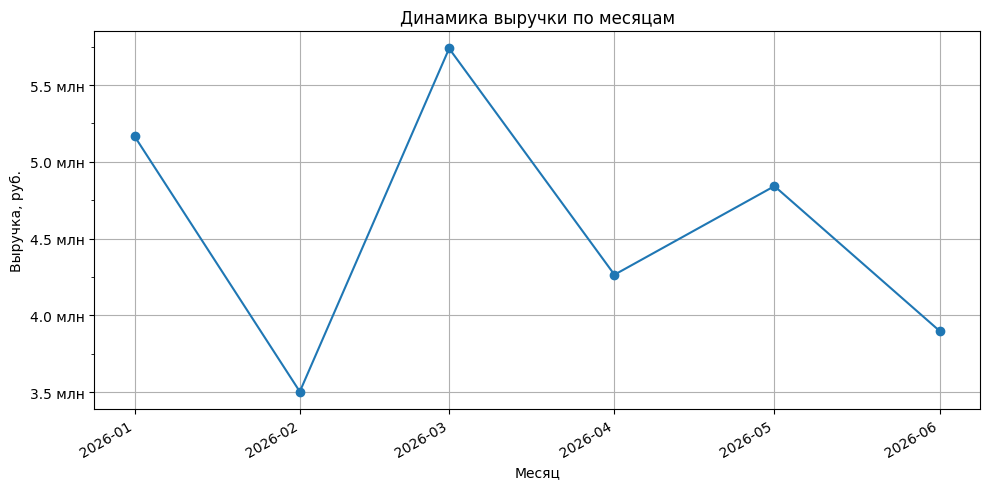

In [5]:
monthly = (df.assign(month=df["order_date"].dt.to_period("M").dt.to_timestamp())
             .groupby("month", as_index=False).agg(revenue=("revenue","sum")))
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(monthly["month"], monthly["revenue"], marker="o")
ax.set_title("Динамика выручки по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Выручка, руб.")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} млн"))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "case_01_monthly_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

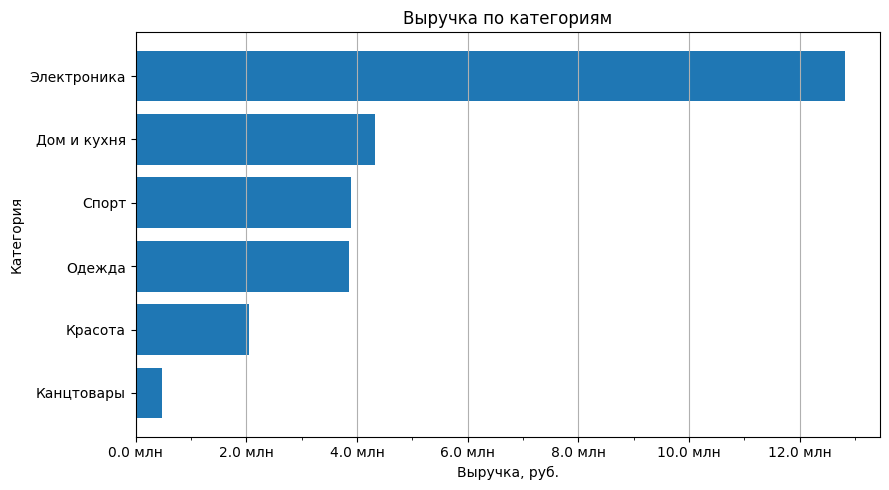

In [6]:
cat = df.groupby("category", as_index=False).agg(revenue=("revenue","sum"), profit=("profit","sum")).sort_values("revenue", ascending=True)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(cat["category"], cat["revenue"])
ax.set_title("Выручка по категориям")
ax.set_xlabel("Выручка, руб.")
ax.set_ylabel("Категория")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} млн"))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, axis="x", which="major")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "case_02_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

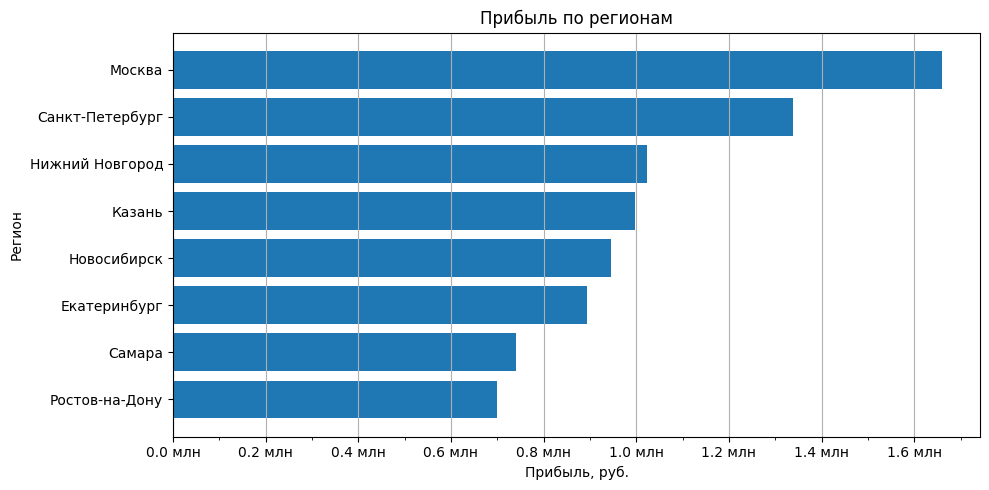

In [7]:
reg = df.groupby("region", as_index=False).agg(profit=("profit","sum")).sort_values("profit", ascending=True)
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(reg["region"], reg["profit"])
ax.set_title("Прибыль по регионам")
ax.set_xlabel("Прибыль, руб.")
ax.set_ylabel("Регион")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f} млн"))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, axis="x", which="major")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "case_03_region_profit.png", dpi=150, bbox_inches="tight")
plt.show()

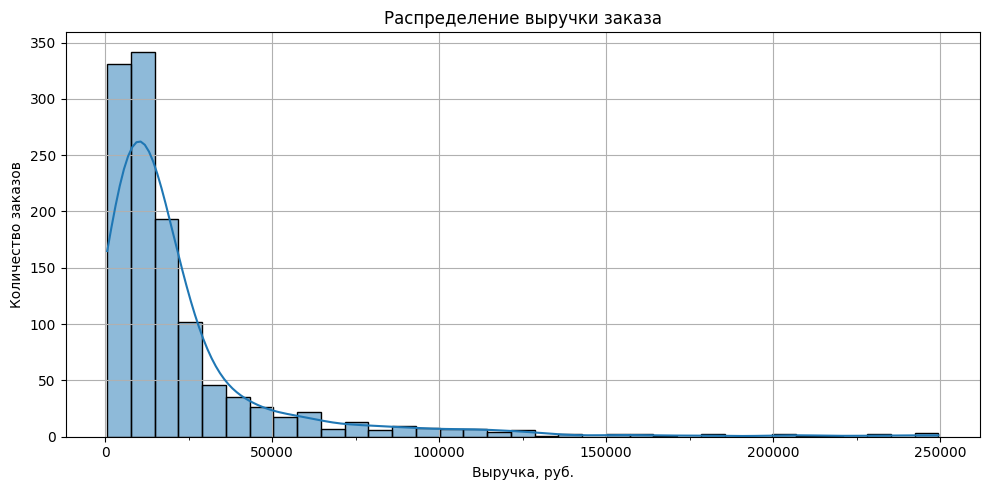

In [8]:
fig, ax = plt.subplots(figsize=(10,5))
default_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]
sns.histplot(data=df, x="revenue", bins=35, kde=True, color=default_color, ax=ax)
ax.set_title("Распределение выручки заказа")
ax.set_xlabel("Выручка, руб.")
ax.set_ylabel("Количество заказов")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "case_04_revenue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

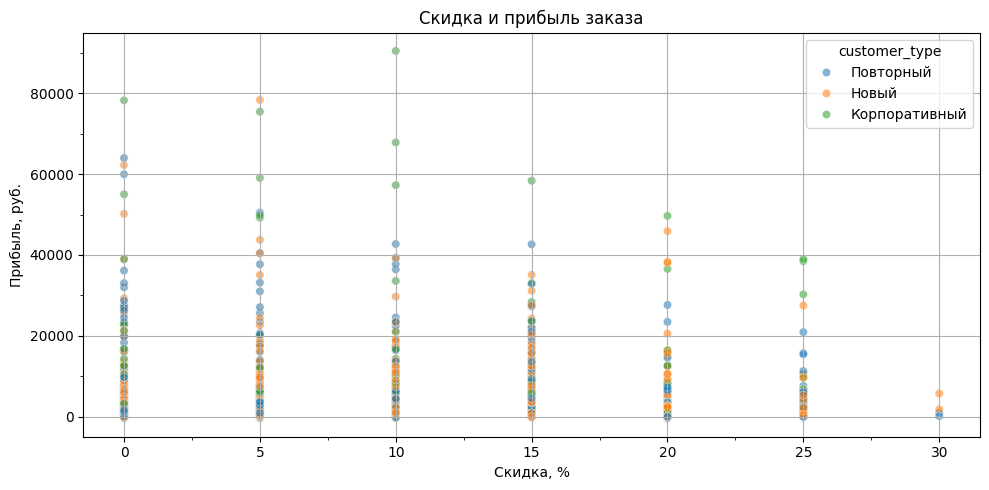

In [9]:
fig, ax = plt.subplots(figsize=(10,5))
sns.scatterplot(data=df, x="discount_percent", y="profit", hue="customer_type", alpha=0.55, ax=ax)
ax.set_title("Скидка и прибыль заказа")
ax.set_xlabel("Скидка, %")
ax.set_ylabel("Прибыль, руб.")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "case_05_discount_profit.png", dpi=150, bbox_inches="tight")
plt.show()

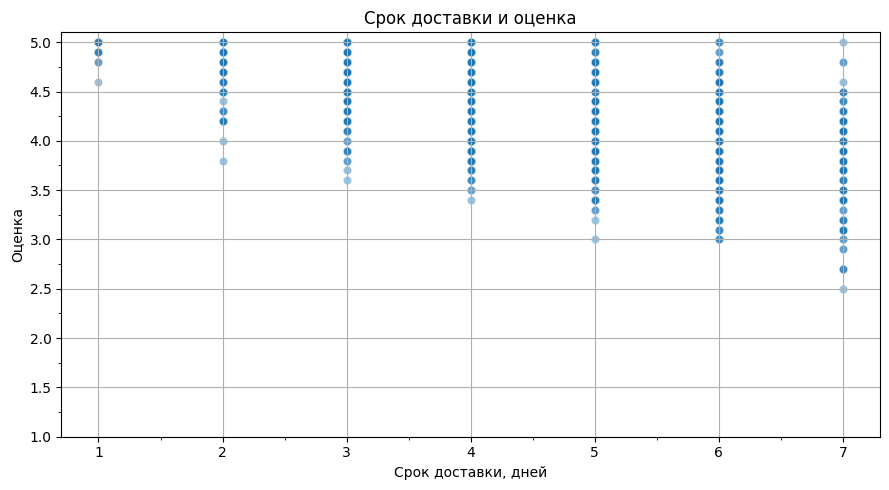

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
sns.scatterplot(data=df, x="delivery_days", y="rating", alpha=0.45, ax=ax)
ax.set_title("Срок доставки и оценка")
ax.set_xlabel("Срок доставки, дней")
ax.set_ylabel("Оценка")
ax.set_ylim(1,5.1)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(True, which="major")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "case_06_delivery_rating.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
summary = {
    "best_month_revenue": monthly.loc[monthly["revenue"].idxmax(), "month"].strftime("%Y-%m"),
    "top_category_revenue": df.groupby("category")["revenue"].sum().idxmax(),
    "top_region_profit": df.groupby("region")["profit"].sum().idxmax(),
    "median_order_revenue": df["revenue"].median(),
    "corr_discount_profit": df[["discount_percent","profit"]].corr().iloc[0,1],
    "corr_delivery_rating": df[["delivery_days","rating"]].corr().iloc[0,1],
}
summary

{'best_month_revenue': '2026-03',
 'top_category_revenue': 'Электроника',
 'top_region_profit': 'Москва',
 'median_order_revenue': np.float64(12809.755000000001),
 'corr_discount_profit': np.float64(-0.060999970648226536),
 'corr_delivery_rating': np.float64(-0.690713671377748)}

## Как разбирать ответы

Допустимы другие графики, если они отвечают на вопрос и не искажают сравнение. Оценивайте не «похожесть на эталон», а цепочку: корректная агрегация → подходящий визуальный канал → читаемые оси → вывод, подтвержденный графиком → ограничение.